# Exploratory data analysis

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency, f_oneway 
import os

In [3]:
os.environ['KAGGLE_API_TOKEN']="KGAT_c4b8c4a5b524f94cc4e808ab917d6f41"

In [ ]:
import kagglehub

path = kagglehub.dataset_download("ravalsmit/customer-segmentation-data",output_dir='./dataset')

c:\Users\oumai\Desktop\customer segmentation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pd.read_csv("./dataset/customer_segmentation_data.csv")

In [7]:
df.tail()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
53498,44809,35,Female,Divorced,Associate Degree,Andaman and Nicobar Islands,Salesperson,120850,policy3,01-01-2019,Mobile App,policy1,586401,4404,Family,In-Person Meeting,Phone,Afternoon,German,Segment5
53499,65485,61,Male,Single,Doctorate,Himachal Pradesh,Entrepreneur,122309,policy5,5/18/2021,Mobile App,policy4,637733,1285,Group,Text,Mail,Afternoon,German,Segment1
53500,26213,25,Male,Divorced,Doctorate,Assam,Teacher,49258,policy2,11/27/2018,In-Person,policy1,631057,4407,Individual,Text,Text,Weekends,French,Segment4
53501,63136,42,Male,Married,Doctorate,Andhra Pradesh,Artist,66301,policy4,06-04-2021,In-Person,policy1,730385,4482,Business,Mail,Phone,Morning,French,Segment5
53502,62125,20,Male,Divorced,Doctorate,Daman and Diu,Salesperson,136632,policy2,10/14/2022,Phone,policy1,743262,4499,Group,Text,In-Person Meeting,Evening,German,Segment2


In [8]:
df.isna().sum()

Customer ID                           0
Age                                   0
Gender                                0
Marital Status                        0
Education Level                       0
Geographic Information                0
Occupation                            0
Income Level                          0
Behavioral Data                       0
Purchase History                      0
Interactions with Customer Service    0
Insurance Products Owned              0
Coverage Amount                       0
Premium Amount                        0
Policy Type                           0
Customer Preferences                  0
Preferred Communication Channel       0
Preferred Contact Time                0
Preferred Language                    0
Segmentation Group                    0
dtype: int64

In [9]:
df.dtypes

Customer ID                           int64
Age                                   int64
Gender                                  str
Marital Status                          str
Education Level                         str
Geographic Information                  str
Occupation                              str
Income Level                          int64
Behavioral Data                         str
Purchase History                        str
Interactions with Customer Service      str
Insurance Products Owned                str
Coverage Amount                       int64
Premium Amount                        int64
Policy Type                             str
Customer Preferences                    str
Preferred Communication Channel         str
Preferred Contact Time                  str
Preferred Language                      str
Segmentation Group                      str
dtype: object

In [10]:
# convert purchase history to datetime

df['Purchase History'] = pd.to_datetime(df['Purchase History'],format='mixed')

In [11]:
df.drop(columns=['Segmentation Group'],inplace=True) # remove the segmentation group column

## Univariate analysis:
### Categorical variables:

In [104]:
cat_column = [col for col in df.columns if df[col].dtype == 'str']
cat_column

['Gender',
 'Marital Status',
 'Education Level',
 'Geographic Information',
 'Occupation',
 'Behavioral Data',
 'Interactions with Customer Service',
 'Insurance Products Owned',
 'Policy Type',
 'Customer Preferences',
 'Preferred Communication Channel',
 'Preferred Contact Time',
 'Preferred Language']

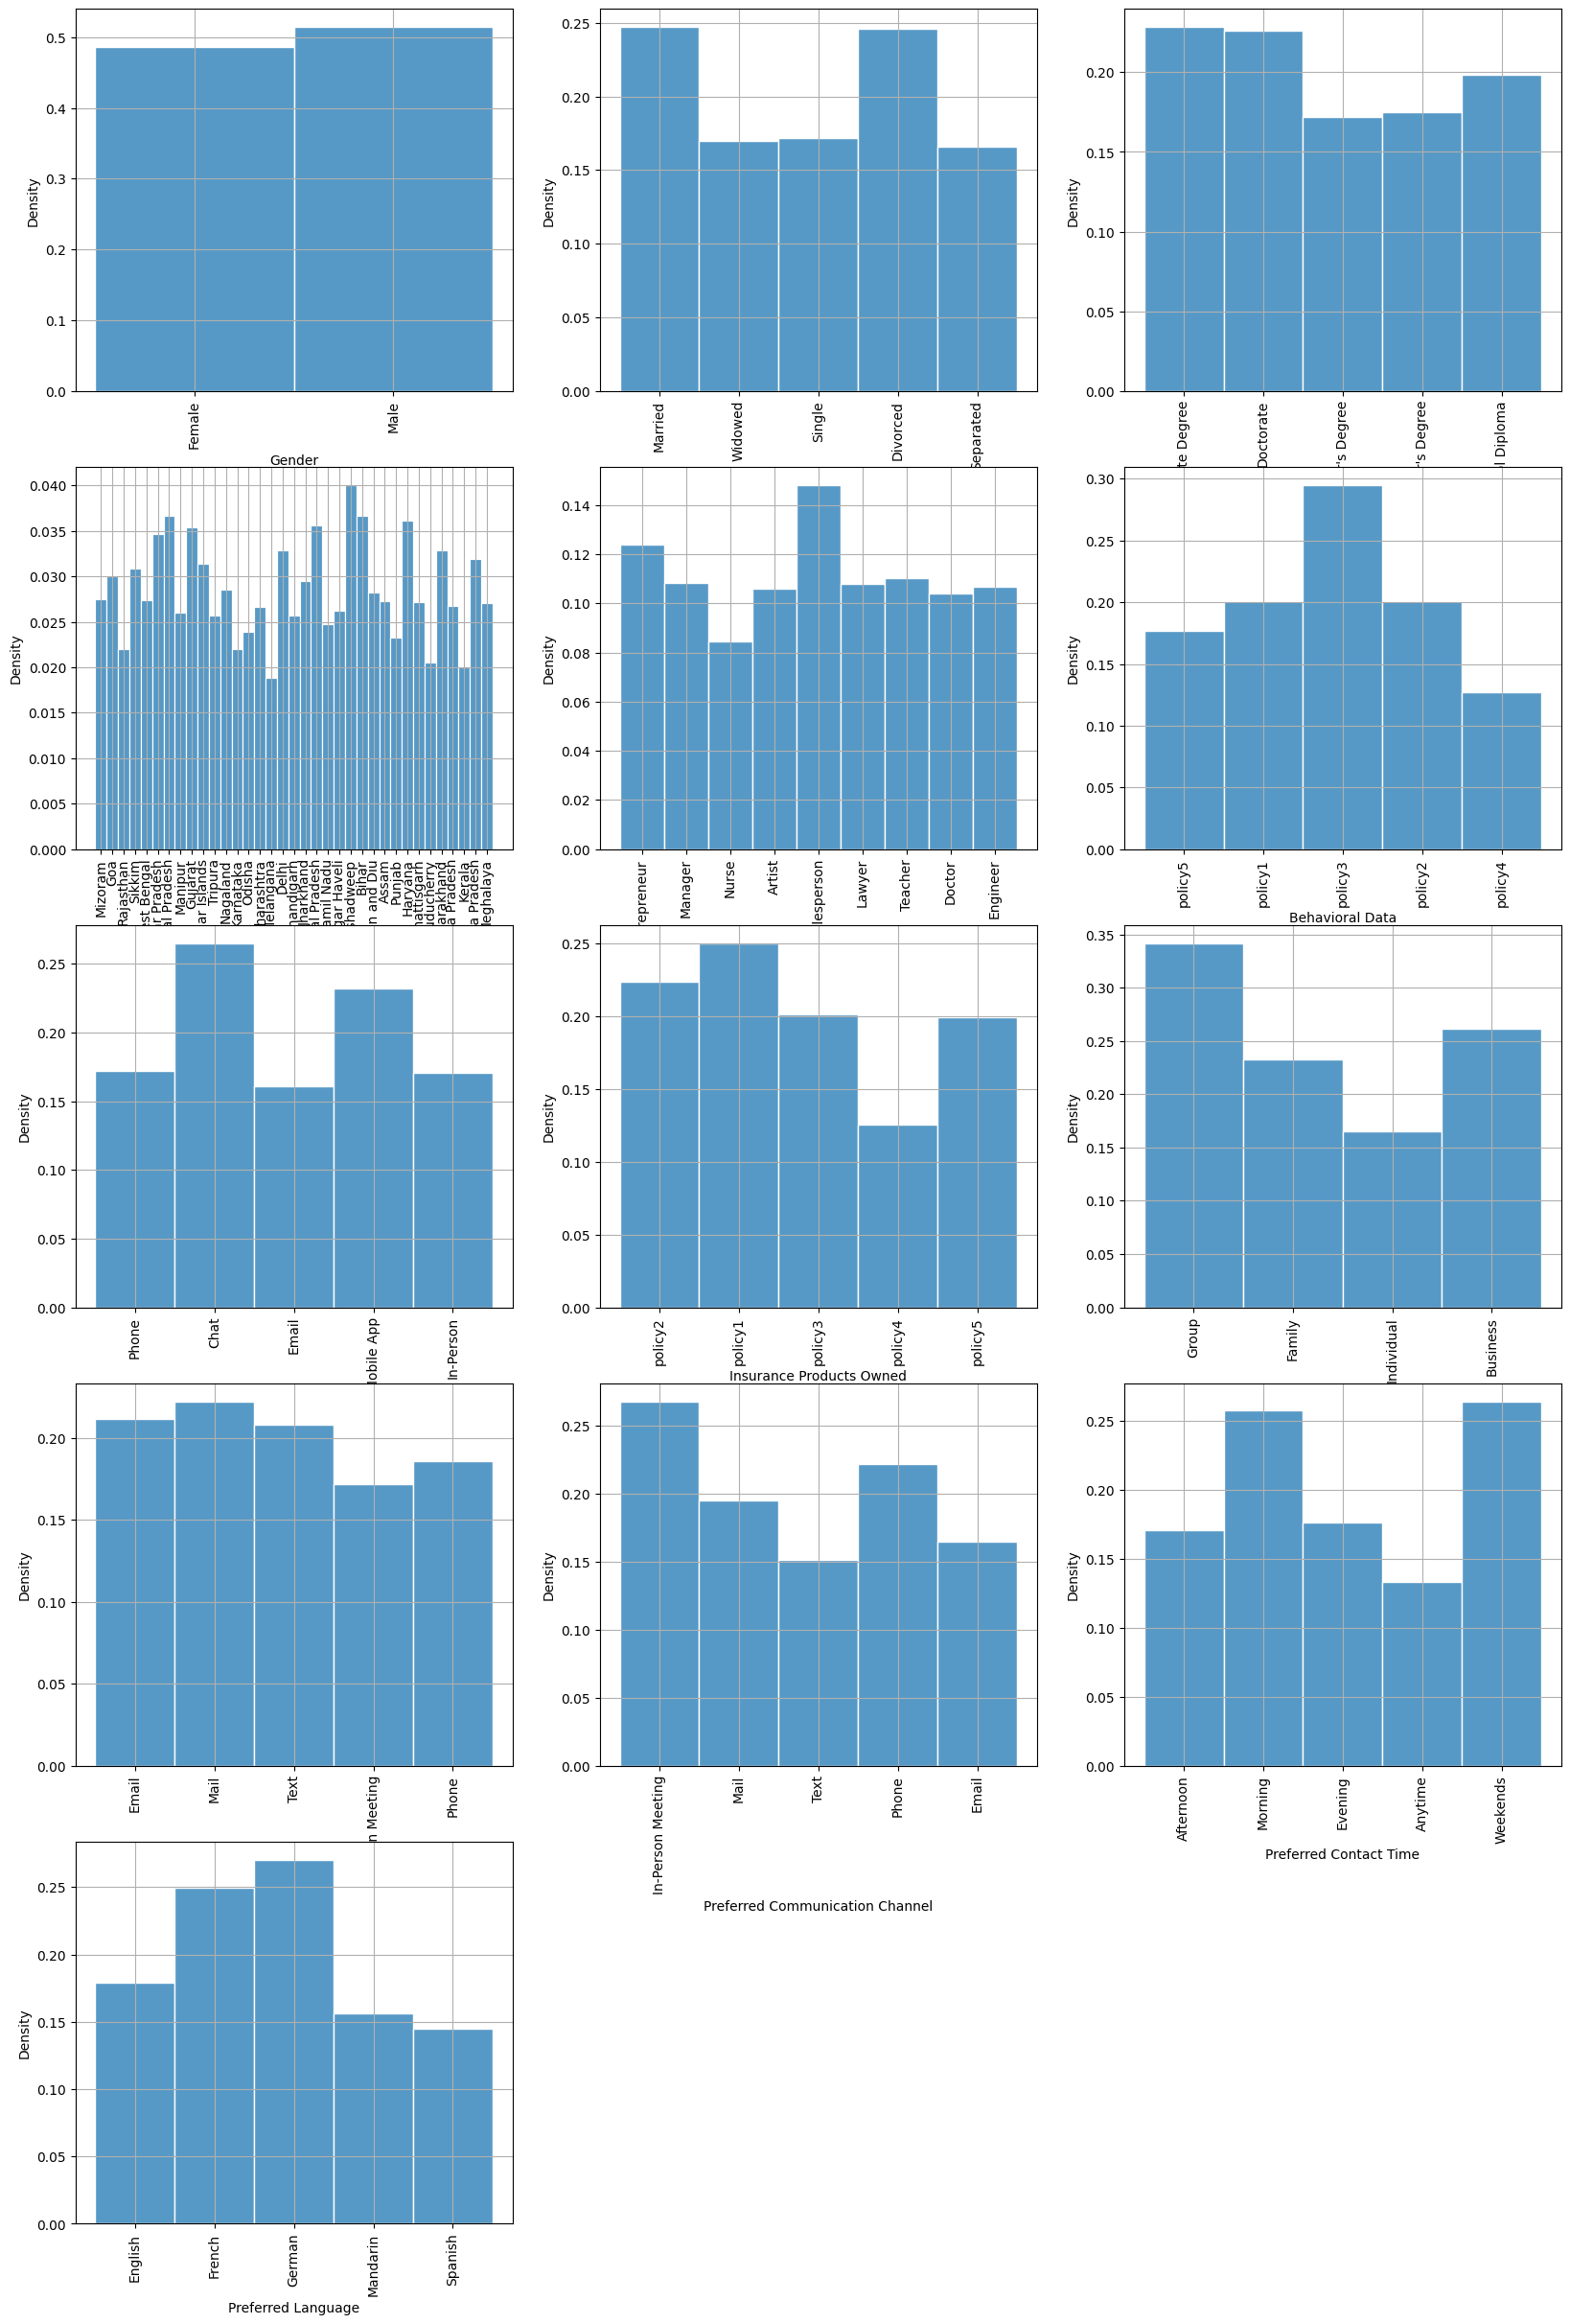

In [105]:
i = 1
plt.figure(figsize=(20,30))
for col in cat_column:
    plt.subplot(5,3,i)
    sns.histplot(x=df[col], edgecolor="white",bins=60,stat='density')
    plt.grid()
    plt.xticks(rotation=90)
    i+=1

plt.show()
    

there isn't a big difference between the numbers of males and females in the dataset, 50% are either married or divorced, around 30% behavioral data are policy3, more than 50%'s preferred contact time are morning and weekends, more than 25% prefer german.

### Numerical variables:

In [14]:
num_column = [col for col in df.columns if col not in str_column]
num_column.remove('Customer ID') # we don't need it here
num_column

['Age',
 'Income Level',
 'Purchase History',
 'Coverage Amount',
 'Premium Amount']

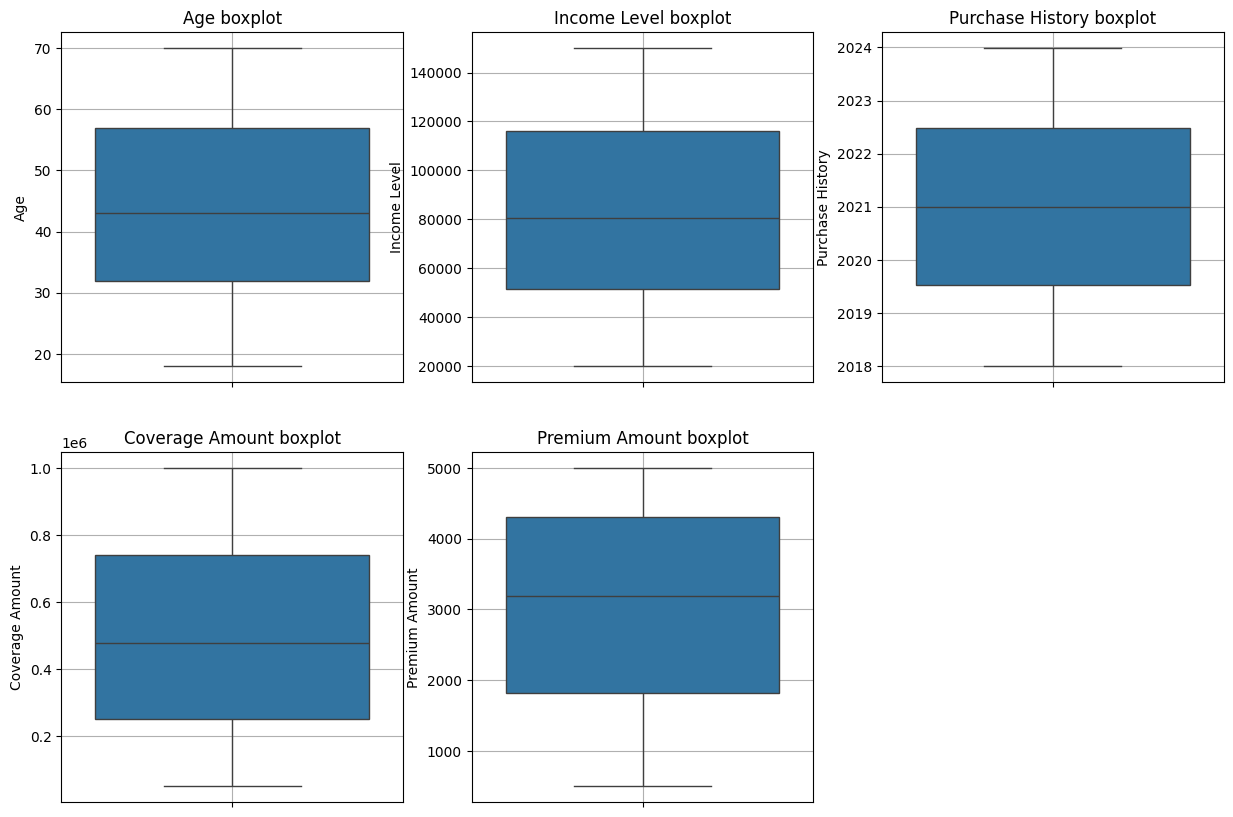

In [15]:
plt.figure(figsize=(15,10))

i=1
for col in num_column:
    plt.subplot(2,3,i)
    sns.boxplot(df[col])
    plt.title(f"{col} boxplot")
    plt.grid()
    i+=1

plt.show()

there is no outlier values.

## Bivariate analysis:
### Two categorical variables:

In [106]:
cat_var = dict()

for i in range(len(cat_column)-1):
    col1 = cat_column[i]
    for j in range(i+1,len(cat_column)):
        col2 = cat_column[j]
        table = pd.crosstab(df[col1],df[col2],margins=True)
        stat, p_value, dof, expected = chi2_contingency(table)

        cat_var[f'{col1} & {col2}'] = [float(stat), float(p_value), 'dependent' if p_value<=0.05 else 'independent']

In [107]:
cat_var_sorted = dict(sorted(cat_var.items(),key=lambda item:item[1][1]))

for key in cat_var_sorted.keys():
    print(f'{key} = {cat_var_sorted[key]}')

Geographic Information & Customer Preferences = [697.7280566759132, 1.5842110474546892e-63, 'dependent']
Occupation & Preferred Communication Channel = [366.1731780276392, 6.462951970412891e-52, 'dependent']
Geographic Information & Preferred Communication Channel = [620.4870586756211, 3.8283187023898547e-51, 'dependent']
Marital Status & Interactions with Customer Service = [310.6433052428862, 4.3729802373664575e-51, 'dependent']
Behavioral Data & Preferred Communication Channel = [302.8861821550763, 1.5841388009141727e-49, 'dependent']
Customer Preferences & Preferred Communication Channel = [297.84738096162107, 1.6246683093643342e-48, 'dependent']
Geographic Information & Behavioral Data = [598.8023971489072, 9.150892230045953e-48, 'dependent']
Geographic Information & Interactions with Customer Service = [582.8030740378756, 2.6490632922194095e-45, 'dependent']
Geographic Information & Preferred Language = [581.1996736295316, 4.658763764361169e-45, 'dependent']
Education Level & Geo

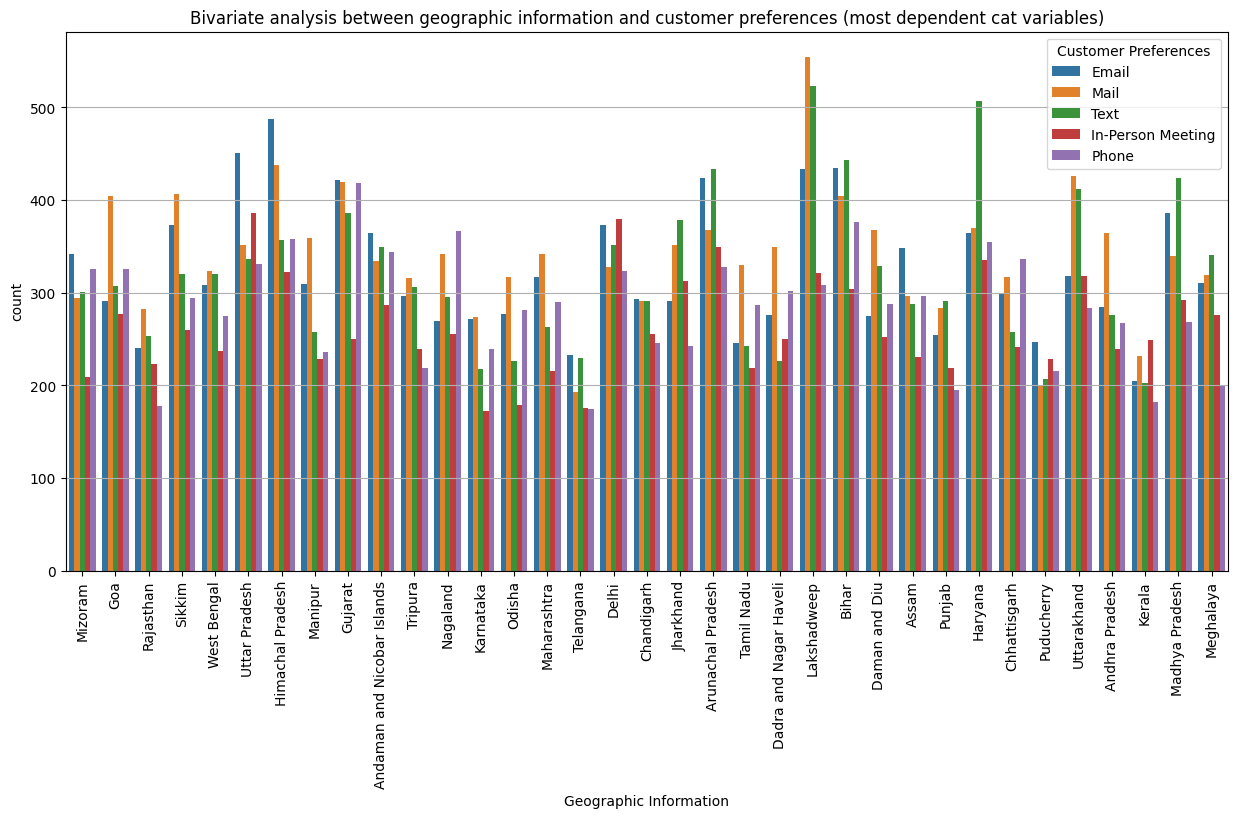

In [108]:
plt.figure(figsize=(15,7))
plt.grid()
plt.title('Bivariate analysis between geographic information and customer preferences (most dependent cat variables)')
sns.countplot(x='Geographic Information',hue='Customer Preferences',data=df)
plt.xticks(rotation=90)
plt.show()

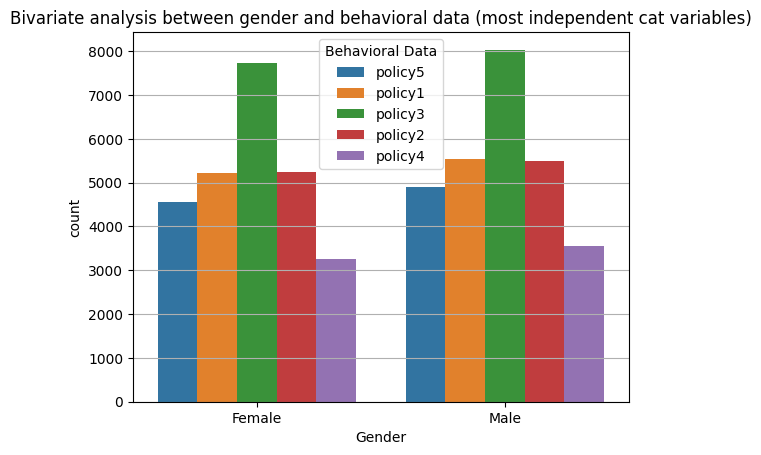

In [109]:
plt.grid()
plt.title('Bivariate analysis between gender and behavioral data (most independent cat variables)')
sns.countplot(x='Gender',hue='Behavioral Data',data=df)
plt.show()

we can conclude that there is quite a significate relationship between most of the catagorical variables, except between gender and behavioral data which are independent from each other as we can see in the graph above.

### Numerical variables:

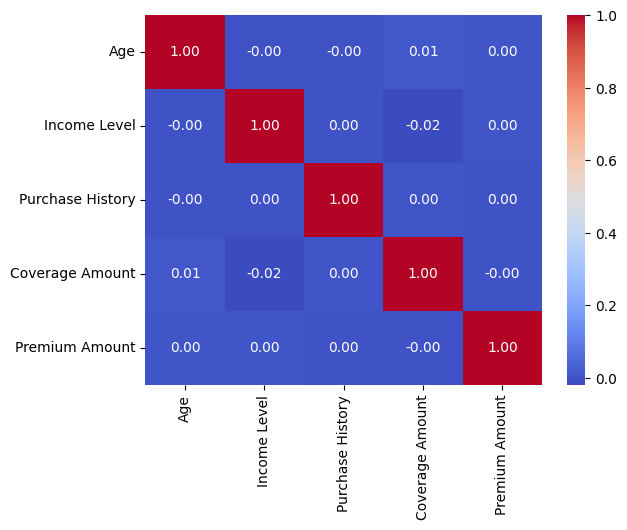

In [110]:
sns.heatmap(df[num_column].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

as shown by the correlation matrix, there is no correlation between the different numerical variables.

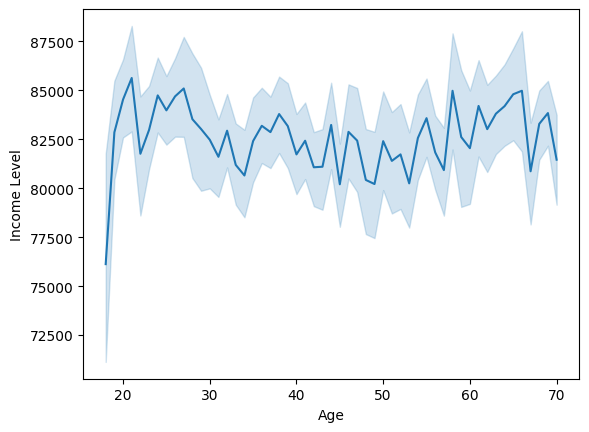

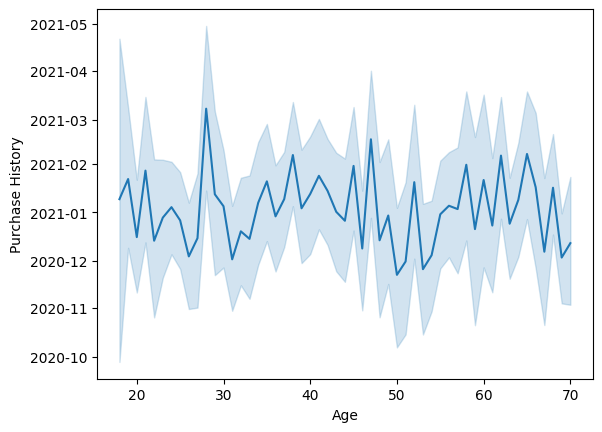

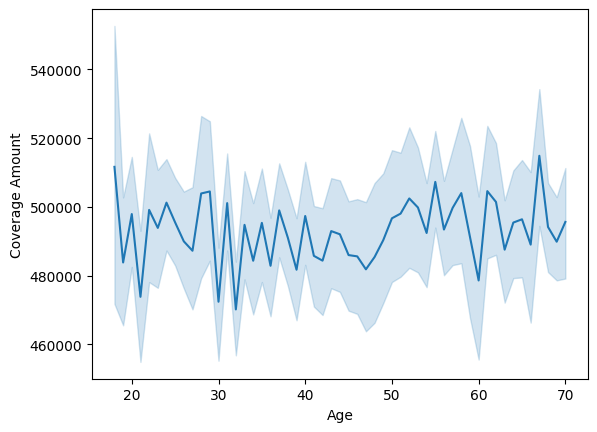

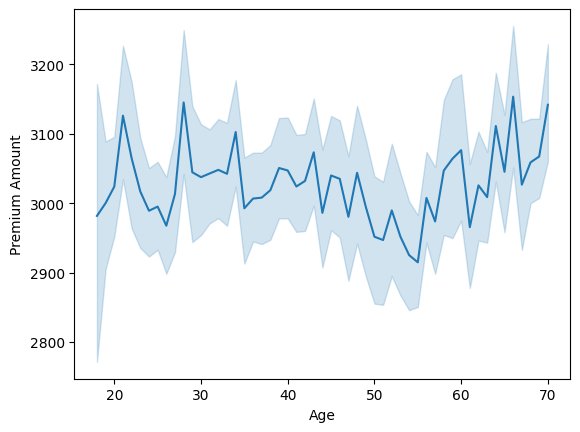

In [64]:
for col in num_column:
    if col != 'Age':
        sns.lineplot(x=df['Age'],y=df[col])
        plt.show()

We can observe some dependence between the customer's age and the income, in fact the income is significantly smaller at early ages (17-20 years, around 76000) which is pretty natural, then stays between 77500 and 87500. However for the other variables, it looks pretty much random.

### Categorical & numerical variables:

In [24]:
t_stat, p_value = ttest_ind(df['Age'][df['Gender']=='Male'],df['Age'][df['Gender']=='Female'])
print(f'T statistic: {t_stat}\np_value: {p_value}')

T statistic: -6.49004826440247
p_value: 8.655655464206063e-11


p_value < 0.05: the age and gender are dependent.

In [37]:
t_stat, p_value = ttest_ind(df['Income Level'][df['Gender']=='Male'],df['Income Level'][df['Gender']=='Female'])
print(f'T statistic: {t_stat}\np_value: {p_value}')

T statistic: 2.2803673603545866
p_value: 0.02258982491779991


the income level and gender are dependent since the p_value < 0.05.

In [38]:
t_stat, p_value = ttest_ind(df['Coverage Amount'][df['Gender']=='Male'],df['Coverage Amount'][df['Gender']=='Female'])
print(f'T statistic: {t_stat}\np_value: {p_value}')

T statistic: 0.5161955172137683
p_value: 0.6057199942340656


the coverage amount and the gender are independent since p_value > 0.05.

In [47]:
t_stat, p_value = ttest_ind(df['Premium Amount'][df['Gender']=='Male'],df['Premium Amount'][df['Gender']=='Female'])
print(f'T statistic: {t_stat}\np_value: {p_value}')

T statistic: -6.957259945927115
p_value: 3.5092864394837744e-12


according to the result, there is a significant relationship between the gender and the premium amount.

In [66]:
def anova_test(df,num_variable,cat_variable):
    list_categories = [category for category in dict(df[cat_variable].value_counts()).keys()]
    list_groupes = [df[num_variable][df[cat_variable]==category] for category in list_categories]

    anova_stat, p_value = f_oneway(*list_groupes)

    return float(anova_stat), float(p_value)

In [ ]:
sns.histplot(data=df,x=num_col,hue=df[cat_col])

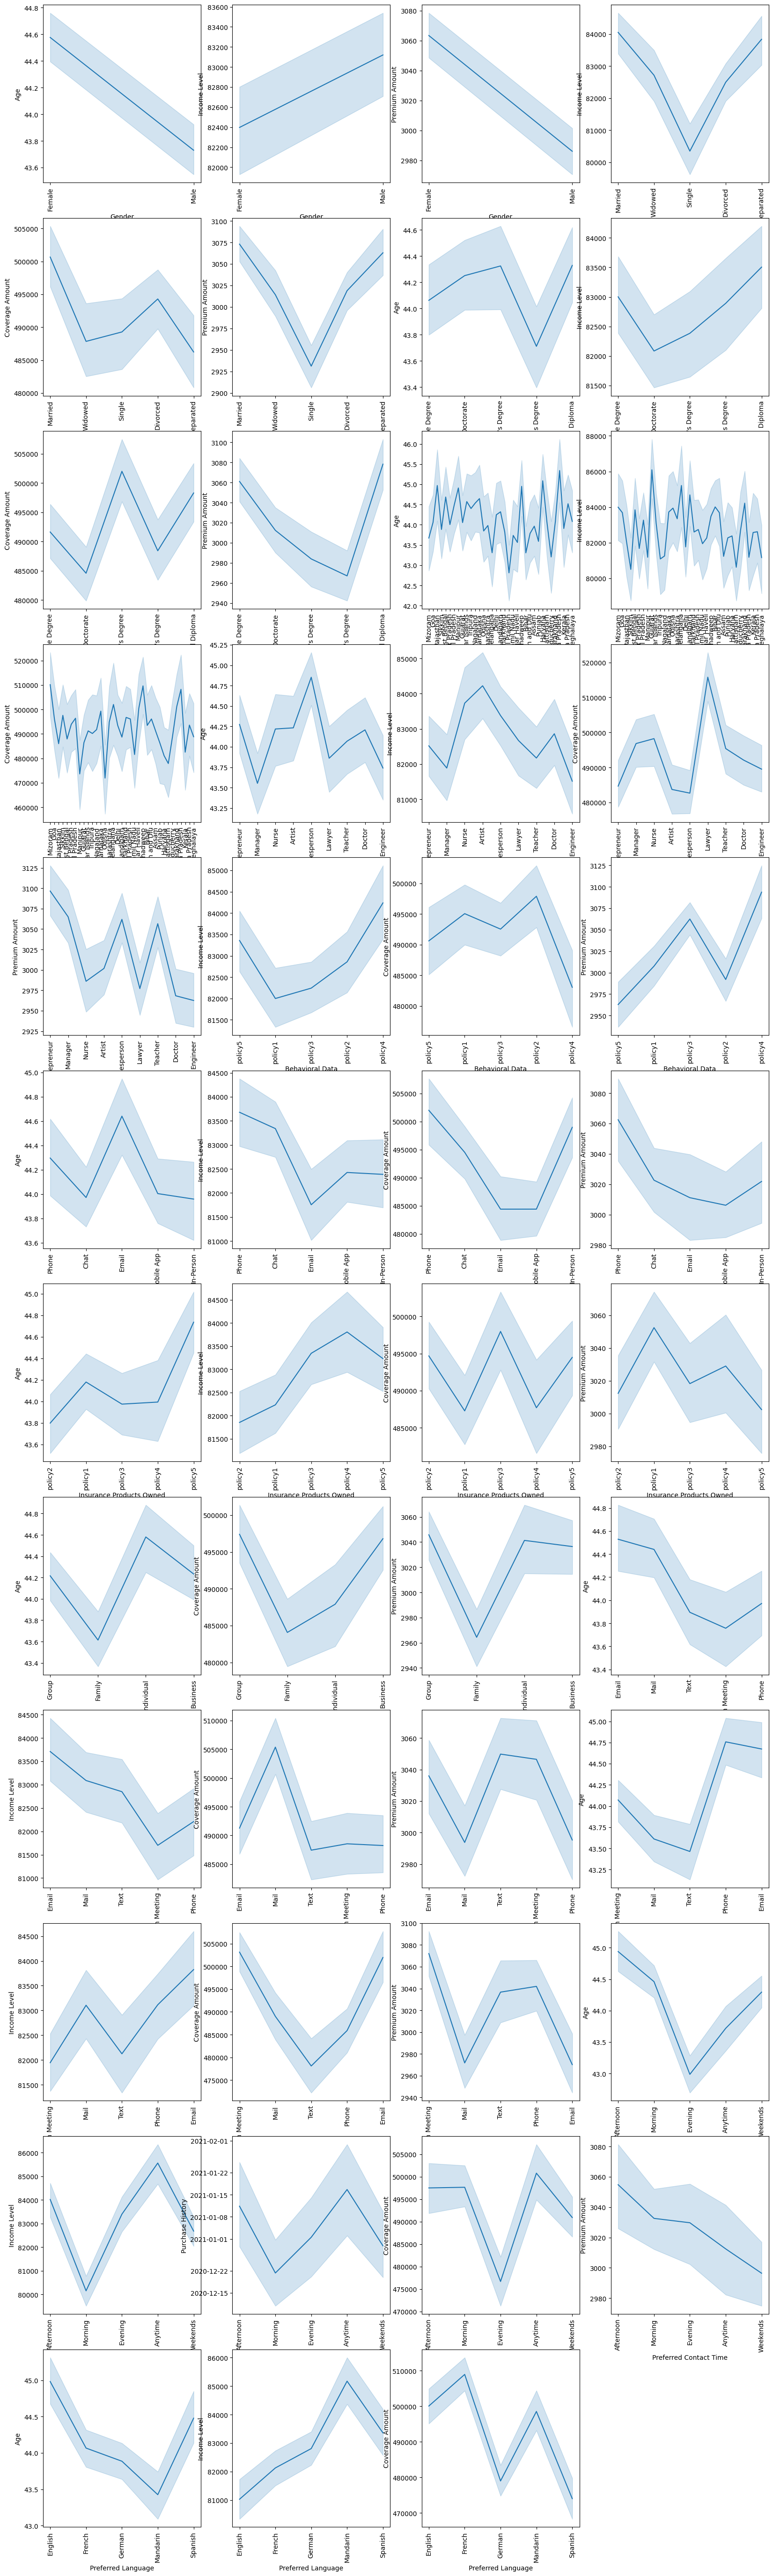

In [111]:
cat_num_var = dict()

i = 1

plt.figure(figsize=(20,70))

for cat_col in cat_column:
    for num_col in num_column:
        anova_stat, p_value = anova_test(df,num_col,cat_col)
        cat_num_var[f"{cat_col} & {num_col}"] = [anova_stat,p_value]

        if p_value <= 0.05: # if the variable are dependent of each other
            plt.subplot(12,4,i)
            sns.lineplot(data=df,x=cat_col,y=num_col)
            plt.xticks(rotation=90)
            i+=1
plt.show()
